# Run Correlation-Based Analyses

### Authors: Calvin Howard.

#### Last updated: July 6, 2023

Use this to assess if a correlation between a dependent variable and an independent variable is statistically significant using permutation analysis. 

Further, follow this up with a contrast analysis which sees which categorical variables have significantly different correlations from each other. 

Notes:
- To best use this notebook, you should be familar with mixed effects models

# 00 - Import CSV with All Data
**The CSV is expected to be in this format**
- ID and absolute paths to niftis are critical
```
+-----+----------------------------+--------------+--------------+--------------+
| ID  | Nifti_File_Path            | Covariate_1  | Covariate_2  | Covariate_3  |
+-----+----------------------------+--------------+--------------+--------------+
| 1   | /path/to/file1.nii.gz      | 0.5          | 1.2          | 3.4          |
| 2   | /path/to/file2.nii.gz      | 0.7          | 1.4          | 3.1          |
| 3   | /path/to/file3.nii.gz      | 0.6          | 1.5          | 3.5          |
| 4   | /path/to/file4.nii.gz      | 0.9          | 1.1          | 3.2          |
| ... | ...                        | ...          | ...          | ...          |
+-----+----------------------------+--------------+--------------+--------------+
```

In [1]:
# Specify the path to your CSV file containing NIFTI paths
input_csv_path = '/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_Atrophy/metadata/cleaned_information/validation_mtl-q4.csv'
sheet = None #"Sheet1" #'master_list_proper_subjects' 

In [2]:
# Specify where you want to save your results to
out_dir = '/Users/cu135/Partners HealthCare Dropbox/Calvin Howard/studies/atrophy_seeds_2023/Figures/supplement_validation_corr-to-q4'

In [3]:
from calvin_utils.permutation_analysis_utils.statsmodels_palm import CalvinStatsmodelsPalm
# Instantiate the PalmPrepararation class
cal_palm = CalvinStatsmodelsPalm(input_csv_path=input_csv_path, output_dir=out_dir, sheet=sheet)
# Call the process_nifti_paths method
data_df = cal_palm.read_and_display_data()


# 01 - Preprocess Your Data

**Handle NANs**
- Set drop_nans=True is you would like to remove NaNs from data
- Provide a column name or a list of column names to remove NaNs from

In [4]:
data_df.columns

Index(['Tissue', 'MTL_Atrophy', 'Q4', 'TOTAL11', 'TOTALMOD', 'DX_BASELINE',
       'DX_M12'],
      dtype='object')

In [5]:
drop_list = ['MTL_Atrophy', 'Q4']

In [6]:
data_df = cal_palm.drop_nans_from_columns(columns_to_drop_from=drop_list)
display(data_df)

,Tissue,MTL_Atrophy,Q4,TOTAL11,TOTALMOD,DX_BASELINE,DX_M12
0,CSF,-1947.061673,10.0,19.33,30.33,Alzheimer,Alzheimer
1,CSF,-1808.785280,9.0,20.67,31.67,Alzheimer,NaN
2,CSF,-94.284543,8.0,9.00,17.00,Alzheimer,Alzheimer
19,CSF,-1600.680328,8.0,15.33,25.33,Alzheimer,Alzheimer
20,CSF,-4405.871162,10.0,30.33,42.33,Alzheimer,Alzheimer
...,...,...,...,...,...,...,...
3964,CTH,-4.054863,2.0,NaN,NaN,NaN,NaN
3965,CTH,3.076742,7.0,NaN,NaN,NaN,NaN
3975,CTH,-0.789857,5.0,NaN,NaN,NaN,NaN
3976,CTH,-2.228461,3.0,NaN,NaN,NaN,NaN


**Drop Row Based on Value of Column**

Define the column, condition, and value for dropping rows
- column = 'your_column_name'
- condition = 'above'  # Options: 'equal', 'above', 'below'

Set the parameters for dropping rows

In [7]:
data_df.columns
# data_df.City.unique()

Index(['Tissue', 'MTL_Atrophy', 'Q4', 'TOTAL11', 'TOTALMOD', 'DX_BASELINE',
       'DX_M12'],
      dtype='object')

In [ ]:
column = 'Cognitive_Test'  # The column you'd like to evaluate
condition = 'equal'  # Thecondition to check ('equal', 'above', 'below', 'not')
value = 'UPDRS-1' # The value to compare against

In [ ]:
# data_df, other_df = cal_palm.drop_rows_based_on_value(column, condition, value)
data_df

Regress out a Covariate

In [ ]:
lis = []
for col in data_df.columns:
    if 'surface' in col.lower():
        lis.append(col)
print(lis)

In [ ]:
from calvin_utils.statistical_utils.regression_utils import RegressOutCovariates
# use this code block to regress out covariates. Generally better to just include as covariates in a model..
dependent_variable_list = lis
regressors = ['Age', 'Sex']

# data_df, adjusted_dep_vars_list = RegressOutCovariates.run(df=data_df, dependent_variable_list=dependent_variable_list, covariates_list=regressors)
# print(adjusted_dep_vars_list)

**Standardize Data**
- Enter Columns you Don't want to standardize into a list

In [ ]:
data_df.columns

In [ ]:
# Remove anything you don't want to standardize
cols_not_to_standardize = ['Cohort', 'Age', 'Z_Scored_Percent_Cognitive_Improvement', 'MinMaxNormBaseline_Higher_is_Better']

In [ ]:
data_df = cal_palm.standardize_columns(cols_not_to_standardize)
data_df

In [ ]:
data_df.describe()

# 05 - Delta Scatterplot (Pretty)
- Generates 2 categories to compare by splitting on a continuous variable

In [19]:
data_df.columns

Index(['Tissue', 'MTL_Atrophy', 'Q4', 'TOTAL11', 'TOTALMOD', 'DX_BASELINE',
       'DX_M12'],
      dtype='object')

In [8]:
data_df.loc[data_df['Tissue']=='CSF', ['MTL_Atrophy']] *= -1

Data To Plot

In [9]:
# Data Variables
dependent_variable = 'Q4'
independent_variable = 'MTL_Atrophy'
group_variable = 'Tissue' # This is the column which contains the values you are going to split the data by 

Labels for Plot

Number of unique groups in 'Tissue': 4
Group 'CSF' has 561 values.
Group 'Standard Methods' has 1425 values.


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


(<Figure size 288x324 with 1 Axes>, <Figure size 288x324 with 1 Axes>)

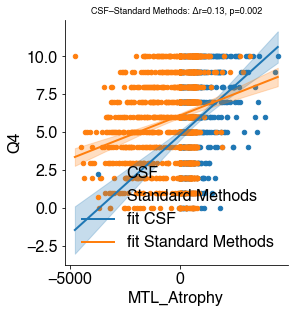

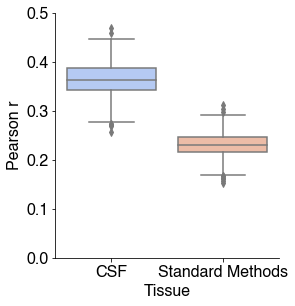

In [12]:
from calvin_utils.statistical_utils.delta_r import DeltaCorrelationAnalysis
swc = DeltaCorrelationAnalysis(data_df)
swc.run(x=independent_variable, y=dependent_variable, group=group_variable, xlim=(0, .5), horiz_box=False,
        out_dir=out_dir, focus_category='CSF', rest_label='Standard Methods')